In [1]:
from transition_fn import transition_fn_by_lin_reg
import pandas as pd
import numpy as np
from state import State,StateValidator
import timeit
import matplotlib.pyplot as plt

In [2]:
def t_table_gen_by_lin_reg(validator: StateValidator) -> pd.DataFrame:
    """
    Generate a transition probability table using a linear regression-based transition function.
      The resulting transition table is ensured to be square and each column sums to 1.
    
    Arguments:
      validator (StateValidator): The validator to generate a state space
    
    Returns:
      pd.DataFrame:
          A square DataFrame where both the rows and columns are states.
          Each cell (i, j) represents the probability of transitioning from state i to state j.
    """
    assert isinstance(validator, StateValidator), "Passed validator is not an instance of `StateValidator`"
    complete_index = pd.Index([State(generated).as_tuple() for generated in validator.gen_state_space()])
    to_ret: pd.DataFrame = pd.DataFrame(columns=complete_index)
    times = []
    for state in validator.gen_state_space():
        start = timeit.default_timer()
        state = State(state)
        zeroes = pd.Series(np.zeros(len(complete_index)),index=complete_index)
        prob_vec = transition_fn_by_lin_reg(state,validator)
        # new_index = [str((*state[1:], n)) for n in prob_vec.index]
        new_index = [state.get_next_state(n).as_tuple() for n in prob_vec.index]
        prob_vec.index = new_index
        assert prob_vec.index.equals(pd.Index(new_index)), f"Not equal: new_index={new_index}\nprob_vec.index={prob_vec.index}"

        assert np.isclose(np.sum(prob_vec),1), f"prob_vec for {state} is not 1 but is {np.sum(prob_vec)}"
        zeroes.update(prob_vec)
        to_ret[state.as_tuple()] = zeroes
        end = timeit.default_timer()
        times.append(end - start)

    assert to_ret.columns.size == to_ret.index.size, "Not a square t table"

    return to_ret,times


In [39]:
val = StateValidator(3,3)
t_table_gen_by_lin_reg(val)


/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)
/home/main/Documents/Assignments/Stoch/markovian-stock-modeling/venv/lib/python3.10/site-packages/numpy/polynomial/polynomial.py:1476: RankWarning: The fit may be poorly conditioned
  return pu._fit(polyvander, x, y, deg, rcond, full, w)


(                    -1                                                    \
                     -1                             0                       
                     -1         0         1        -1         0         1   
 -1 -1 -1  9.830526e-01  0.000000  0.000000  0.000000  0.000000  0.000000   
        0  1.694743e-02  0.000000  0.000000  0.000000  0.000000  0.000000   
        1  9.830803e-11  0.000000  0.000000  0.000000  0.000000  0.000000   
     0 -1  0.000000e+00  0.638163  0.000000  0.000000  0.000000  0.000000   
        0  0.000000e+00  0.355173  0.000000  0.000000  0.000000  0.000000   
        1  0.000000e+00  0.006664  0.000000  0.000000  0.000000  0.000000   
     1 -1  0.000000e+00  0.000000  0.429842  0.000000  0.000000  0.000000   
        0  0.000000e+00  0.000000  0.381779  0.000000  0.000000  0.000000   
        1  0.000000e+00  0.000000  0.188380  0.000000  0.000000  0.000000   
  0 -1 -1  0.000000e+00  0.000000  0.000000  0.638163  0.000000  0.000000   

In [ ]:
row_generation_times = pd.Series()
p_matrix_gen_times = pd.Series()
p_matrix_memory_usages = pd.Series()
for num_states in range(3,23,2):
    print(num_states)
    val = StateValidator(num_states,3)
    start = timeit.default_timer()
    p_matrix, sample_time = t_table_gen_by_lin_reg(val)
    end = timeit.default_timer()
    sample_time = pd.Series(sample_time)
    row_generation_times = pd.concat([row_generation_times,pd.Series([sample_time.mean()],index=[num_states])])
    p_matrix_gen_times= pd.concat([p_matrix_gen_times,pd.Series([end-start],index=[num_states])])
    p_matrix_memory_usages = pd.concat([p_matrix_memory_usages,pd.Series([p_matrix.memory_usage().sum()],index=[num_states])])


Text(0, 0.5, 'Mean Time(in thousandths of a second)')

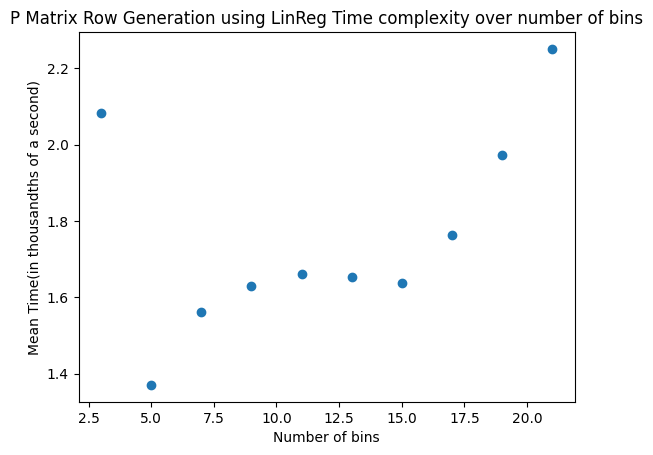

In [16]:
plt.scatter(row_generation_times.index,row_generation_times*1000)
plt.title("P Matrix Row Generation using LinReg Time complexity over number of bins")
plt.xlabel("Number of bins")
plt.ylabel("Mean Time(in thousandths of a second)")

Text(0, 0.5, 'Mean Time(seconds)')

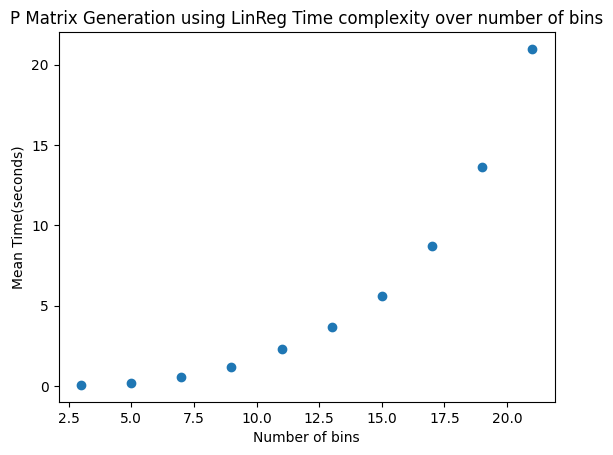

In [17]:
plt.scatter(p_matrix_gen_times.index,p_matrix_gen_times)
plt.title("P Matrix Generation using LinReg Time complexity over number of bins")
plt.xlabel("Number of bins")
plt.ylabel("Mean Time(seconds)")

Text(0, 0.5, 'Memory Usage in Megabytes')

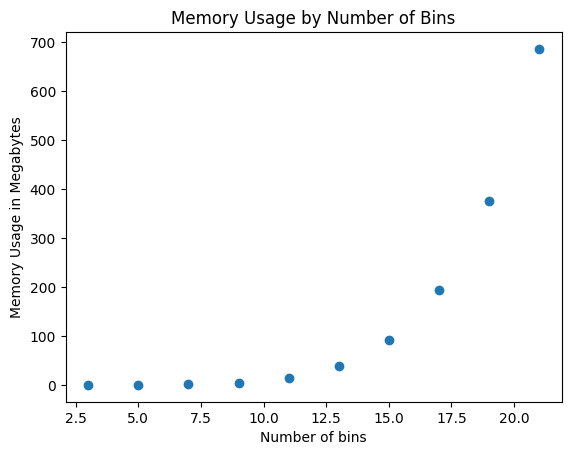

In [21]:
plt.scatter(p_matrix_memory_usages.index,p_matrix_memory_usages/10**6)
plt.title("Memory Usage by Number of Bins")
plt.xlabel("Number of bins")
plt.ylabel("Memory Usage in Megabytes")